In [ ]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
import pymaster as nmt
from astropy.io import fits
import scipy as sp
import pandas as pd
from scipy.stats import ks_2samp

import scipy.optimize as opt
from scipy.optimize import curve_fit

# load the RGB values from file
from matplotlib.colors import ListedColormap

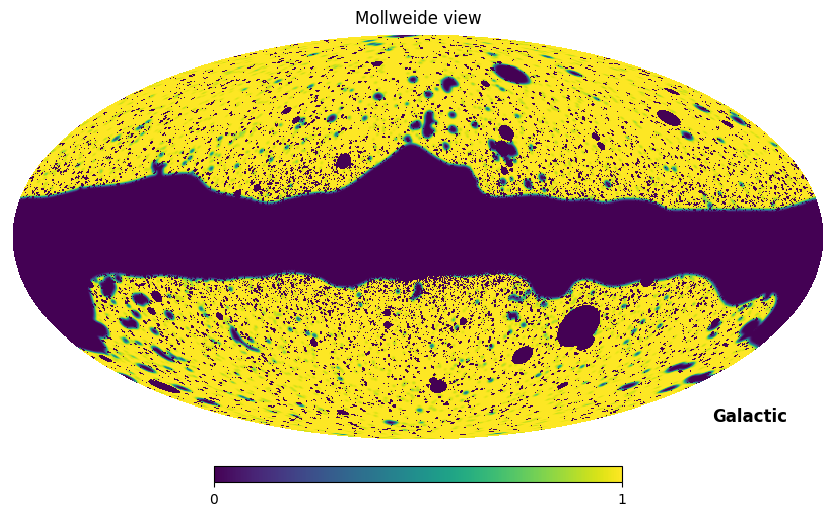

In [2]:
unWISE_mask = hp.read_map("/home/gscianna/codes/kSZ_unWISE/masks/mask_unWISE_full_v10_C.fits")
hp.mollview(unWISE_mask, coord=['C', 'G'])

In [3]:
# mask = hp.read_map("/home/gscianna/codes/kSZ_unWISE/masks/mask.fits")

# samples = {
#     "blue": hp.read_map("../galaxy_samples/1_delta.fits", field=0),
#     "green": hp.read_map("../galaxy_samples/2_delta.fits", field=0),
#     "red": hp.read_map("../galaxy_samples/7_delta.fits", field=0),
# }

delta_blue = hp.read_map("/home/gscianna/codes/kSZ_unWISE/ola_data/1_delta.fits", field=0)
delta_green = hp.read_map("/home/gscianna/codes/kSZ_unWISE/ola_data/2_delta.fits", field=0)
delta_red = hp.read_map("/home/gscianna/codes/kSZ_unWISE/ola_data/7_delta.fits", field=0)

# ell_max = 3000
# delta_ell = 100

# b = nmt.NmtBin.from_edges(
#     np.arange(0, ell_max, delta_ell),
#     np.arange(delta_ell, ell_max + delta_ell, delta_ell)
# )

# ell_arr = b.get_effective_ells()

cmap = plt.cm.viridis.copy()
cmap.set_bad("gray")
cmap.set_under("white")

In [4]:
def compute_master(f_a, f_b, wsp):
    cl_coupled = nmt.compute_coupled_cell(f_a, f_b)
    cl_decoupled = wsp.decouple_cell(cl_coupled)

    return cl_decoupled

In [5]:
arr_blue = np.array([
    [250, 0.08750000000000001],
    [350, 0.057236842105263155],
    [450, 0.043421052631578944],
    [550, 0.035526315789473684],
    [650, 0.030263157894736853],
    [750, 0.026973684210526316],
    [850, 0.024342105263157887],
    [950, 0.021710526315789486]
])

arr_green = np.array([
    [150, 0.1473684210526316],
    [250, 0.08881578947368422],
    [350, 0.06250000000000001],
    [450, 0.04934210526315791],
    [550, 0.04144736842105265],
    [650, 0.035526315789473684],
    [750, 0.032236842105263175],
    [850, 0.029605263157894773],
    [950, 0.027631578947368424]
])

arr_red = np.array([
    [150, 0.49090909090909096],
    [250, 0.41636363636363644],
    [350, 0.37181818181818194],
    [450, 0.3490909090909091],
    [550, 0.33090909090909093],
    [650, 0.3263636363636364],
    [750, 0.31818181818181823],
    [850, 0.3172727272727274],
    [950, 0.3145454545454546]
])

### data from krolewski for comparison

In [6]:
l_min = 200
l_max = 1000
delta_l = 100

ells_low = np.arange(l_min, l_max, delta_l)
ells_high = ells_low + delta_l
ells_high[-1] = l_max + 1

b = nmt.NmtBin.from_edges(ells_low, ells_high)

# shot_noise = 1. / hp.nside2npix(nside) / np.mean(delta_blue + 1)

In [7]:
# diff = (cl_decoupled[0] - arr_blue[:, 1])
# diff

In [8]:
gal_blue = nmt.NmtField(unWISE_mask, [delta_blue], lmax=l_max)
gal_green = nmt.NmtField(unWISE_mask, [delta_green], lmax=l_max)
gal_red = nmt.NmtField(unWISE_mask, [delta_red], lmax=l_max)

### delta_blue

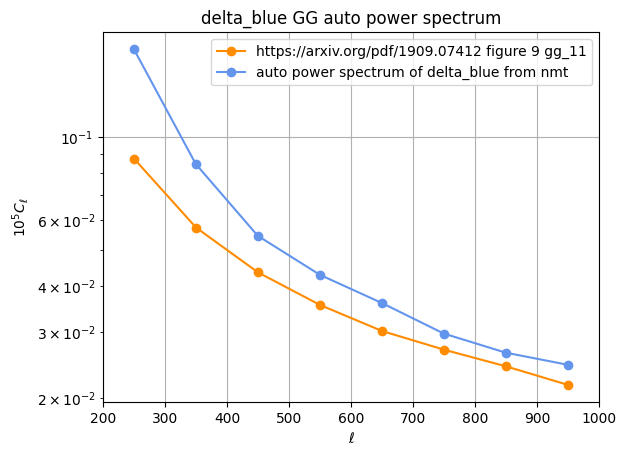

In [9]:
wsp_gal_blue = nmt.NmtWorkspace()
wsp_gal_blue.compute_coupling_matrix(gal_blue, gal_blue, b)
auto_gal = compute_master(gal_blue, gal_blue, wsp_gal_blue)

cl_coupled_blue = nmt.compute_coupled_cell(gal_blue, gal_blue)
cl_decoupled_blue = wsp_gal_blue.decouple_cell(cl_coupled_blue)
ell = b.get_effective_ells()

plt.plot(
    arr_blue[:, 0],
    arr_blue[:, 1],
    color="darkorange",
    marker='o',
    linestyle='-',
    label="https://arxiv.org/pdf/1909.07412 figure 9 gg_11"
)

plt.plot(
    ell,
    1e5 * cl_decoupled_blue[0],
    color="cornflowerblue",
    marker='o',
    linestyle='-',
    label="auto power spectrum of delta_blue from nmt"
)

plt.xlabel(r"$\ell$")
plt.ylabel(r"$10^5 C_\ell$")
plt.yscale("log")
plt.xlim(200, 1000)
plt.title("delta_blue GG auto power spectrum")
plt.grid()
plt.legend()
plt.show()

In [10]:
cl_blue_nmt = 1e5 * cl_decoupled_blue[0]
cl_blue_ola = arr_blue[:, 1]

### delta_green

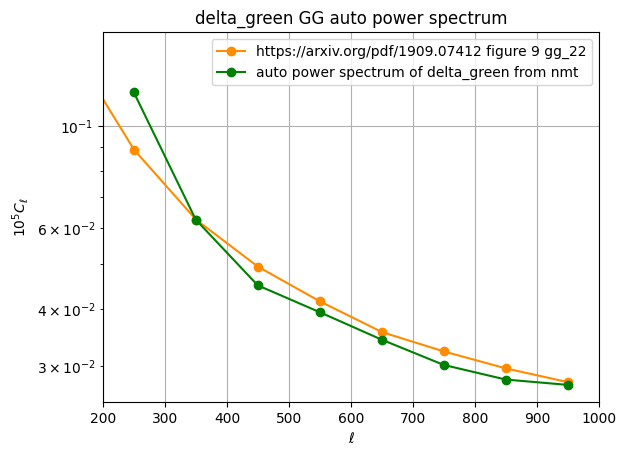

In [11]:
wsp_gal_green = nmt.NmtWorkspace()
wsp_gal_green.compute_coupling_matrix(gal_green, gal_green, b)
auto_gal_green = compute_master(gal_green, gal_green, wsp_gal_green)

cl_coupled_green = nmt.compute_coupled_cell(gal_green, gal_green)
cl_decoupled_green = wsp_gal_green.decouple_cell(cl_coupled_green)
ell_green = b.get_effective_ells()

plt.plot(
    arr_green[:, 0],
    arr_green[:, 1],
    marker="o",          # scatter points
    linestyle="-",       # line connecting points
    color="darkorange",
    label="https://arxiv.org/pdf/1909.07412 figure 9 gg_22"
)

plt.plot(
    ell_green,
    1e5 * cl_decoupled_green[0],
    marker="o",
    linestyle="-",
    color="green",
    label="auto power spectrum of delta_green from nmt"
)

plt.xlabel(r"$\ell$")
plt.ylabel(r"$10^5 C_\ell$")
plt.yscale("log")
plt.xlim(200, 1000)
plt.title("delta_green GG auto power spectrum")
plt.grid()
plt.legend()
plt.show()

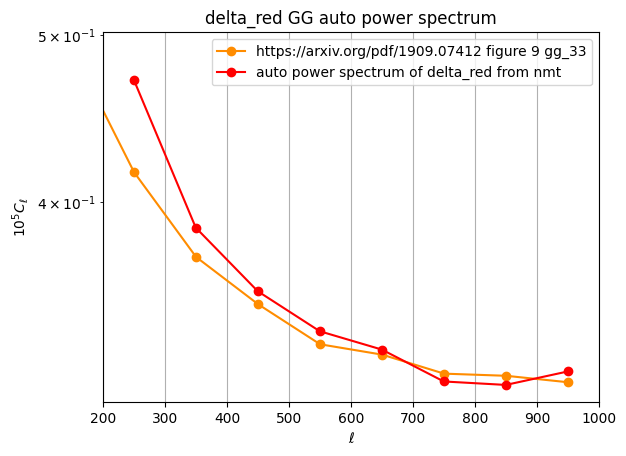

In [12]:
wsp_gal_red = nmt.NmtWorkspace()
wsp_gal_red.compute_coupling_matrix(gal_red, gal_red, b)
auto_gal_red = compute_master(gal_red, gal_red, wsp_gal_red)

cl_coupled_red = nmt.compute_coupled_cell(gal_red, gal_red)
cl_decoupled_red = wsp_gal_red.decouple_cell(cl_coupled_red)
ell_red = b.get_effective_ells()

plt.plot(
    arr_red[:, 0],
    arr_red[:, 1],
    color="darkorange",
    marker='o',
    linestyle='-',
    label="https://arxiv.org/pdf/1909.07412 figure 9 gg_33"
)

plt.plot(
    ell_red,
    1e5 * cl_decoupled_red[0],
    color="red",
    marker='o',
    linestyle='-',
    label="auto power spectrum of delta_red from nmt"
)

plt.xlabel(r"$\ell$")
plt.ylabel(r"$10^5 C_\ell$")
plt.yscale("log")
plt.xlim(200, 1000)
plt.title("delta_red GG auto power spectrum")
plt.grid()
plt.legend()
plt.show()

In [13]:
print(unWISE_mask.min(), unWISE_mask.max())

# count intermediate pixels
np.sum((unWISE_mask > 0) & (unWISE_mask < 1))

0.0 1.0


np.int64(32310881)

In [ ]:
df = pd.DataFrame({
    'nmt': cl_blue_nmt,
    'ola': cl_blue_ola
})

# define samples

nmt = df['nmt'].dropna()
ola = df['ola'].dropna()

statistic, p_value = ks_2samp(nmt, ola)
print("Kolmogorov-Smirnov Test:")
print(f"D-statistic: {statistic}")
print(f"P-value: {p_value}")

#assuming 0.05 confidence level

if p_value < 0.05:
    print('Null hypthesis rejected, sampled from different distributions')
else:
    print("Null hypothesis accepted")

Kolmogorov-Smirnov Test:
D-statistic: 0.25
P-value: 0.98010878010878
Null hypothesis accepted
